In [26]:
import numpy as np
import random
import matplotlib.pyplot as plt

import pywt

from config import *
from utils.display import load_and_display

In [23]:
norm_fmri_img, _ , norm_fmri_data, _ = load_and_display(FMRI_NORM_PATH, "FMRI NORMALIZED", print_info=True)


INFORMATION ABOUT FMRI NORMALIZED NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (91, 109, 91, 200)
Dimensions of the NIfTI image: [  4  91 109  91]
Dimensions of NIfTI img data: (91, 109, 91, 200)
Voxel size (mm): (2.0, 2.0, 2.0, 3.56)


Da qui posso estrarre un dato importante per l'analisi wavelet. In questo caso stiamo analizzando segnali monodimensionali che variano nel tempo, è importante capire con che frequenza acquisisco questi segnali. Dalle informazioni fmri il Repetition Time è di 3.56 secondi, questo vuol dire che acquisisco dati con una frequenza di 0.28 Heartz. Per utilizzare la wavelet, è necessario specificare che parametro di scale vogliamo, per scalare la mother wavelet e catturare dettagli più o meno fini (temporalmente parlando catturare fenomeni che si ripetono nel tempo più o meno veloci). Sappiamo la frequenza di campionamento che è 0.28, quindi non possiamo catturare dettagli più veloci di 0.14 heartz. Quindi come limite potremmo usare 0.10 e come limite minimo potrei usare 0.01

In [19]:
time_series = np.load("time_series.npy")

def getSignals(data, count=4, idxs=None):

    if idxs == None:
        rand_ints = random.sample(range(0,200), count)
        signals = time_series[:,rand_ints]
        return signals
    else:    
        assert (count==len(idxs)) , "Il numero di segnali da estrarre e la lunghezza della lista idxs non matcha!"
        signals = time_series[:,idxs]
        return signals

signals = getSignals(time_series)


In [40]:

TR = 3.56 # seconds
wavelet_name = 'cmor1.5-1.0' 

# Range di frequenze fMRI (0.01 - 0.10 Hz)
f_min = 0.01
f_max = 0.10

# Con questo metodo posso trasformare i limiti di frequenza in limiti di scala
scale_min = pywt.frequency2scale(wavelet_name, f_max * TR)
scale_max = pywt.frequency2scale(wavelet_name, f_min * TR)

# Genera il vettore di scale (es. 40 step intermedi con progressione logaritmica)
scales = np.logspace(np.log10(scale_min), np.log10(scale_max), num=40)

print(len(scales))
print(f"Usa questo range nel tuo CWT: da {scale_min:.2f} a {scale_max:.2f}")

40
Usa questo range nel tuo CWT: da 2.81 a 28.09


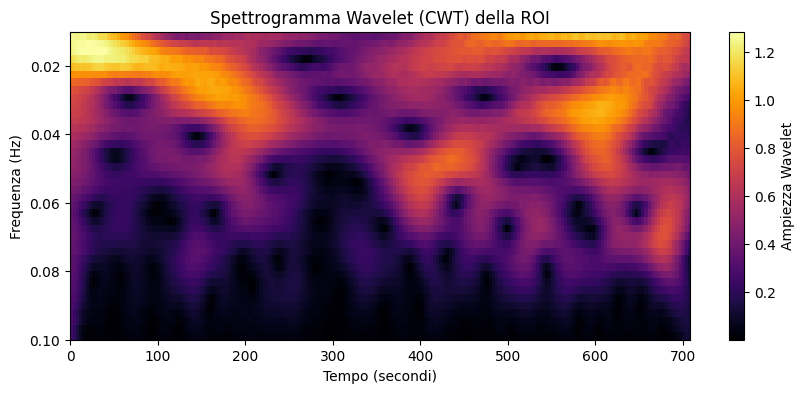

In [48]:
signal_1 = signals[:,1]
signal_1 = signals[:,2]

from scipy.signal import detrend

# Rimuove il drift lineare e centra a zero
signal_clean = detrend(signal_1)
signal_clean = (signal_clean - np.mean(signal_clean)) / np.std(signal_clean)

cwtmatr, freqs = pywt.cwt(signal_clean, scales=scales, wavelet=wavelet_name, sampling_period=TR)
cwt_magnitude = np.abs(cwtmatr)

time_seconds = np.arange(len(signal_clean)) * TR

plt.figure(figsize=(10, 4))
plt.imshow(
    cwt_magnitude,
    extent=[time_seconds[0], time_seconds[-1], freqs[-1], freqs[0]],
    aspect="auto",
    cmap="inferno",
)
plt.gca().invert_yaxis()  # Mette le basse frequenze in basso e le alte in alto
plt.colorbar(label="Ampiezza Wavelet")
plt.xlabel("Tempo (secondi)")
plt.ylabel("Frequenza (Hz)")
plt.title("Spettrogramma Wavelet (CWT) della ROI")
plt.show()